# Actuarial Pricing and Reserving: An Integrated Decision Workflow

**The problem.** Insurance companies live or die on two numbers: the premium they charge policyholders today, and the reserves they hold against claims from policies already written. In most organisations these decisions are made by separate teams, on separate data, with separate assumptions — and meet only in the form of a loss ratio on the annual report. The question this notebook answers: **what does a unified pricing-plus-reserving workflow look like, and how should the two views inform a single capital conversation?**

**The approach.**

1. **Pricing side** — simulate a motor portfolio, fit frequency (Poisson GLM vs. gradient-boosted Poisson) and severity (log-gradient boosting) models, build a pure premium, load it into a technical premium, and run rate-adequacy diagnostics by segment × region.
2. **Reserving side** — build a paid-loss triangle for the same book, project IBNR with deterministic chain-ladder, and bootstrap the reserve distribution.
3. **Combined view** — bring pricing margin and reserve percentiles into a single capital table so a committee can read "does this book stand up after booking a P95 reserve?"

**Audience.** Pricing and reserving actuaries, chief underwriting officers, and the finance/risk partners who sit at the intersection of premium adequacy and reserve strength.

## 0. Setup and reproducibility

All randomness is seeded so the portfolio simulation, model fits, bootstrap draws, and final capital view are identical across runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating an insurance portfolio

We simulate 22,000 motor policies with realistic latent processes for frequency (Poisson with driver-age, vehicle-age, mileage, and segment effects) and severity (log-normal with power, age, segment, and region effects). Exposure varies within the year. This is deliberately richer than a textbook example — enough covariate interaction for segment-level rate adequacy to matter, but seeded so results stay reproducible.

In [2]:
n = 22000

portfolio = pd.DataFrame(
    {
        "policy_id": np.arange(1, n + 1),
        "driver_age": np.random.randint(18, 86, size=n),
        "vehicle_age": np.random.randint(0, 21, size=n),
        "vehicle_power": np.random.normal(120, 35, size=n).clip(50, 280),
        "annual_mileage_k": np.random.normal(14, 5, size=n).clip(3, 45),
        "tenure_years": np.random.exponential(4, size=n).clip(0.1, 20),
        "region": np.random.choice(["North", "South", "East", "West"], p=[0.23, 0.31, 0.24, 0.22], size=n),
        "segment": np.random.choice(["standard", "preferred", "high_risk"], p=[0.62, 0.22, 0.16], size=n),
        "distribution": np.random.choice(["agent", "online", "broker"], p=[0.50, 0.30, 0.20], size=n),
        "exposure": np.random.uniform(0.5, 1.0, size=n),
    }
)

# Frequency latent process
freq_linear = (
    -2.25
    + 0.012 * np.maximum(0, 25 - portfolio["driver_age"].to_numpy())
    + 0.010 * portfolio["vehicle_age"].to_numpy()
    + 0.018 * (portfolio["annual_mileage_k"].to_numpy() - 12)
    + 0.11 * (portfolio["segment"].to_numpy() == "high_risk")
    - 0.06 * (portfolio["segment"].to_numpy() == "preferred")
    + 0.08 * (portfolio["region"].to_numpy() == "South")
)

lambda_claims = np.exp(freq_linear) * portfolio["exposure"].to_numpy()
portfolio["claim_count"] = np.random.poisson(lambda_claims)

# Severity latent process (for claims > 0)
sev_linear = (
    8.05
    + 0.0025 * portfolio["vehicle_power"].to_numpy()
    + 0.028 * portfolio["vehicle_age"].to_numpy()
    + 0.12 * (portfolio["segment"].to_numpy() == "high_risk")
    + 0.06 * (portfolio["region"].to_numpy() == "West")
)

avg_sev = np.exp(np.random.normal(loc=sev_linear, scale=0.42, size=n))
portfolio["avg_claim_severity"] = avg_sev
portfolio["total_claim_amount"] = portfolio["claim_count"] * portfolio["avg_claim_severity"]
portfolio["has_claim"] = (portfolio["claim_count"] > 0).astype(int)

portfolio.head()

,policy_id,driver_age,vehicle_age,vehicle_power,annual_mileage_k,tenure_years,region,segment,distribution,exposure,claim_count,avg_claim_severity,total_claim_amount,has_claim
0,1,69,1,101.396591,13.928846,1.921644,East,standard,agent,0.891314,0,3363.076109,0.0,0
1,2,32,10,130.043206,14.801027,0.137134,West,standard,agent,0.985480,0,6528.879586,0.0,0
2,3,78,14,183.530627,14.180774,2.460911,East,preferred,agent,0.707072,0,8582.250357,0.0,0
3,4,38,2,131.023906,24.517519,4.127068,East,standard,online,0.842672,0,7102.464915,0.0,0
4,5,41,15,75.438686,17.799445,0.556428,South,high_risk,broker,0.996125,0,6497.603189,0.0,0


In [3]:
portfolio_summary = pd.Series(
    {
        "policies": len(portfolio),
        "total_exposure": portfolio["exposure"].sum(),
        "claim_frequency_per_policy": portfolio["claim_count"].mean(),
        "claiming_policy_rate": portfolio["has_claim"].mean(),
        "avg_severity_on_policies": portfolio.loc[portfolio["claim_count"] > 0, "avg_claim_severity"].mean(),
        "loss_ratio_base_premium_2000": portfolio["total_claim_amount"].sum() / (2000 * portfolio["exposure"].sum()),
    }
)
portfolio_summary

policies                        22000.000000
total_exposure                  16446.785386
claim_frequency_per_policy          0.093000
claiming_policy_rate                0.087636
avg_severity_on_policies         6475.804526
loss_ratio_base_premium_2000        0.403321
dtype: float64

## 2. Exploratory diagnostics

Before fitting any model, we confirm the portfolio shows the segment-level risk gradients we need — if frequency and pure premium per exposure don't differentiate across segments, no model will rescue us. The table and bar charts below are the quickest visual check that the simulation (and, in production, the data extraction) is sane.

In [4]:
risk_by_segment = (
    portfolio.groupby("segment", as_index=False)
    .agg(
        exposure=("exposure", "sum"),
        frequency=("claim_count", "mean"),
        severity=("avg_claim_severity", "mean"),
        pure_premium=("total_claim_amount", "sum"),
    )
)
risk_by_segment["pure_premium_per_exposure"] = risk_by_segment["pure_premium"] / risk_by_segment["exposure"]
risk_by_segment

,segment,exposure,frequency,severity,pure_premium,pure_premium_per_exposure
0,high_risk,2668.838977,0.092925,7049.649775,2.356736e+06,883.056467
1,preferred,3644.680951,0.092254,6308.182551,2.776407e+06,761.769549
2,standard,10133.265458,0.093287,6359.718737,8.133510e+06,802.654370


C:\Users\diogo\AppData\Local\Temp\ipykernel_11848\584323376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_by_segment, x="segment", y="frequency", ax=ax[0], palette="Blues")
C:\Users\diogo\AppData\Local\Temp\ipykernel_11848\584323376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_by_segment, x="segment", y="pure_premium_per_exposure", ax=ax[1], palette="Reds")


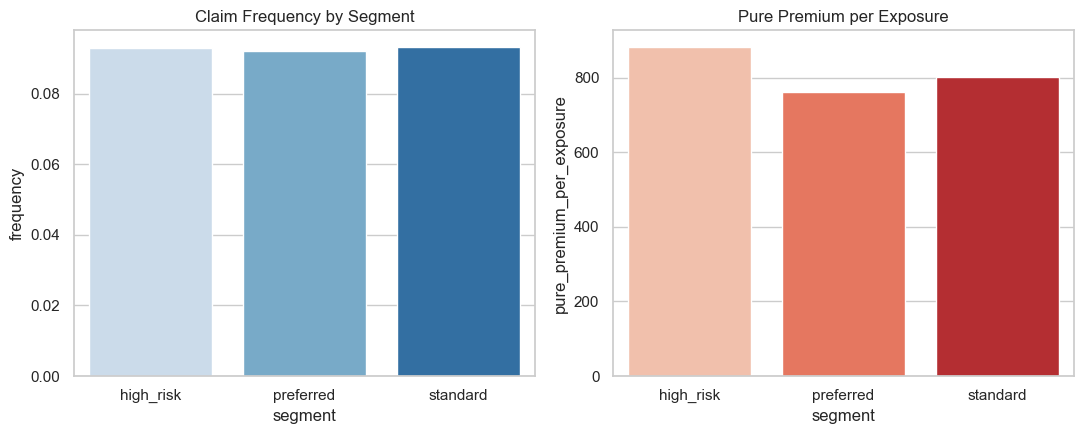

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=risk_by_segment, x="segment", y="frequency", ax=ax[0], palette="Blues")
ax[0].set_title("Claim Frequency by Segment")

sns.barplot(data=risk_by_segment, x="segment", y="pure_premium_per_exposure", ax=ax[1], palette="Reds")
ax[1].set_title("Pure Premium per Exposure")

plt.tight_layout()
plt.show()

**What to read here.** The left bar confirms the segment ordering we expect on frequency (`high_risk` > `standard` > `preferred`). The right bar, pure premium per exposure, is the combined frequency × severity signal — and it should show a meaningfully larger gap than frequency alone because `high_risk` also carries elevated severity. If these two panels were flat or inverted, we would stop and audit the simulation (or the data) rather than fit a model to noise.

## 3. Train/test split and preprocessing

A 70/30 split isolates holdout performance for honest model comparison. Numeric features are standardised (matters for the Poisson GLM, neutral for the gradient booster), categoricals are one-hot encoded. `exposure` enters as a feature rather than an offset for simplicity of side-by-side comparison; a production GLM would use it as an offset to respect the Poisson exposure relationship exactly.

In [6]:
feature_cols = [
    "driver_age",
    "vehicle_age",
    "vehicle_power",
    "annual_mileage_k",
    "tenure_years",
    "region",
    "segment",
    "distribution",
    "exposure",
]

X = portfolio[feature_cols]
y_freq = portfolio["claim_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_freq, test_size=0.30, random_state=42
)

num_cols = ["driver_age", "vehicle_age", "vehicle_power", "annual_mileage_k", "tenure_years", "exposure"]
cat_cols = ["region", "segment", "distribution"]

prep = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

## 4. Frequency model benchmarking

We benchmark two Poisson learners on claim count:

- **Poisson GLM** — the actuarial standard. Interpretable coefficients, defensible to regulators, tends to under-fit genuine non-linearities and interactions.
- **HistGradientBoosting with Poisson loss** — captures interactions and non-linear effects automatically, at the cost of interpretability (recoverable with SHAP / partial dependence if needed downstream).

The better RMSE wins the pure-premium role; we keep the result honest on a held-out 30%.

In [7]:
freq_poisson = Pipeline(
    [
        ("prep", prep),
        ("model", PoissonRegressor(alpha=0.2, max_iter=400)),
    ]
)

freq_hgb = Pipeline(
    [
        ("prep", prep),
        (
            "model",
            HistGradientBoostingRegressor(
                loss="poisson",
                learning_rate=0.07,
                max_depth=5,
                min_samples_leaf=60,
                max_iter=260,
                random_state=42,
            ),
        ),
    ]
)

freq_poisson.fit(X_train, y_train)
freq_hgb.fit(X_train, y_train)

pred_freq_poisson = np.clip(freq_poisson.predict(X_test), 0, None)
pred_freq_hgb = np.clip(freq_hgb.predict(X_test), 0, None)

freq_metrics = pd.DataFrame(
    [
        {
            "model": "PoissonRegressor",
            "mae": mean_absolute_error(y_test, pred_freq_poisson),
            "rmse": np.sqrt(mean_squared_error(y_test, pred_freq_poisson)),
        },
        {
            "model": "HistGB-Poisson",
            "mae": mean_absolute_error(y_test, pred_freq_hgb),
            "rmse": np.sqrt(mean_squared_error(y_test, pred_freq_hgb)),
        },
    ]
).sort_values("rmse")
freq_metrics

,model,mae,rmse
0,PoissonRegressor,0.168821,0.306178
1,HistGB-Poisson,0.169438,0.306634


## 5. Severity model on claiming policies

Severity is fit only on policies with at least one claim — a zero-severity policy is not informative about claim size. We regress on `log1p(severity)` because severity distributions are right-skewed; modelling the log compresses the tail and stabilises tree splits. Predictions are exponentiated back to currency for use in pure premium. A gradient booster (Gaussian loss on log-severity) handles the non-linear segment / region / power interactions more flexibly than a Gamma GLM, with the same interpretability caveat as the frequency side.

In [8]:
sev_df = portfolio[portfolio["claim_count"] > 0].copy()
X_sev = sev_df[feature_cols]
y_sev = np.log1p(sev_df["avg_claim_severity"])  # stabilize tail

X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_sev, y_sev, test_size=0.30, random_state=42
)

sev_model = Pipeline(
    [
        ("prep", prep),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.06,
                max_depth=4,
                min_samples_leaf=45,
                max_iter=280,
                random_state=42,
            ),
        ),
    ]
)

sev_model.fit(X_sev_train, y_sev_train)
sev_pred_log = sev_model.predict(X_sev_test)
sev_pred = np.expm1(sev_pred_log)
sev_true = np.expm1(y_sev_test)

sev_metrics = pd.Series(
    {
        "severity_mae": mean_absolute_error(sev_true, sev_pred),
        "severity_rmse": np.sqrt(mean_squared_error(sev_true, sev_pred)),
    }
)
sev_metrics

severity_mae     2363.678756
severity_rmse    3395.959142
dtype: float64

## 6. Pure premium, technical premium, and rate adequacy

Pure premium = expected frequency × expected severity. The **technical premium** loads it for expenses, profit target, and regional CAT exposure — this is what a policyholder would be quoted before sales discounts. **Rate adequacy ratio** (technical premium / actual pure premium) asks the question underwriters actually care about: for each segment × region cell, does the price we charge cover the loss we observe? A ratio below 1.0 is a subsidy that someone else's book is paying for.

In [9]:
best_freq_name = freq_metrics.iloc[0]["model"]
freq_model = freq_poisson if best_freq_name == "PoissonRegressor" else freq_hgb

portfolio_scored = portfolio.copy()
portfolio_scored["freq_hat"] = np.clip(freq_model.predict(portfolio_scored[feature_cols]), 0, None)
portfolio_scored["sev_hat"] = np.expm1(sev_model.predict(portfolio_scored[feature_cols]))
portfolio_scored["pure_premium_hat"] = portfolio_scored["freq_hat"] * portfolio_scored["sev_hat"]
portfolio_scored["pure_premium_actual"] = portfolio_scored["total_claim_amount"] / portfolio_scored["exposure"]

pricing_diag = pd.Series(
    {
        "selected_frequency_model": best_freq_name,
        "avg_pred_pure_premium": portfolio_scored["pure_premium_hat"].mean(),
        "avg_actual_pure_premium": portfolio_scored["pure_premium_actual"].mean(),
        "premium_gap_pct": (
            portfolio_scored["pure_premium_hat"].mean() / portfolio_scored["pure_premium_actual"].mean() - 1
        )
        * 100,
    }
)
pricing_diag

selected_frequency_model    PoissonRegressor
avg_pred_pure_premium             537.961291
avg_actual_pure_premium           807.512591
premium_gap_pct                   -33.380445
dtype: object

In [10]:
# Convert pure premium into indicated written premium
expense_load = 0.22
profit_load = 0.06
cat_load_by_region = {"North": 0.015, "South": 0.03, "East": 0.02, "West": 0.025}

portfolio_scored["cat_load"] = portfolio_scored["region"].map(cat_load_by_region)
portfolio_scored["technical_premium"] = portfolio_scored["pure_premium_hat"] / (1 - expense_load - profit_load - portfolio_scored["cat_load"])

portfolio_scored[["pure_premium_hat", "technical_premium"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pure_premium_hat,22000.0,537.961291,135.850177,230.345968,437.24421,521.431077,620.330058,1408.943977
technical_premium,22000.0,771.994226,195.611283,326.731869,626.99159,748.312728,889.902289,2041.947793


In [11]:
rate_adequacy = (
    portfolio_scored.groupby(["segment", "region"], as_index=False)
    .agg(
        exposure=("exposure", "sum"),
        avg_indicated_premium=("technical_premium", "mean"),
        avg_actual_loss=("pure_premium_actual", "mean"),
    )
)
rate_adequacy["rate_adequacy_ratio"] = rate_adequacy["avg_indicated_premium"] / rate_adequacy["avg_actual_loss"]
rate_adequacy.sort_values("rate_adequacy_ratio")

,segment,region,exposure,avg_indicated_premium,avg_actual_loss,rate_adequacy_ratio
2,high_risk,South,807.676381,831.914910,1031.733255,0.806328
3,high_risk,West,559.232995,832.166151,952.026826,0.874099
4,preferred,East,905.656634,736.943229,823.869706,0.894490
5,preferred,North,808.444123,672.622326,742.485837,0.905906
10,standard,South,3090.722968,793.315485,869.432621,0.912452
1,high_risk,North,641.807646,741.311811,803.336869,0.922791
6,preferred,South,1152.795772,735.811776,775.176414,0.949218
7,preferred,West,777.784422,748.968214,769.004322,0.973945
8,standard,East,2383.511953,764.898964,776.806061,0.984672
11,standard,West,2236.893878,815.396180,822.029775,0.991930


C:\Users\diogo\AppData\Local\Temp\ipykernel_11848\3181330609.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="rate_adequacy_ratio", y="cell", palette="viridis")


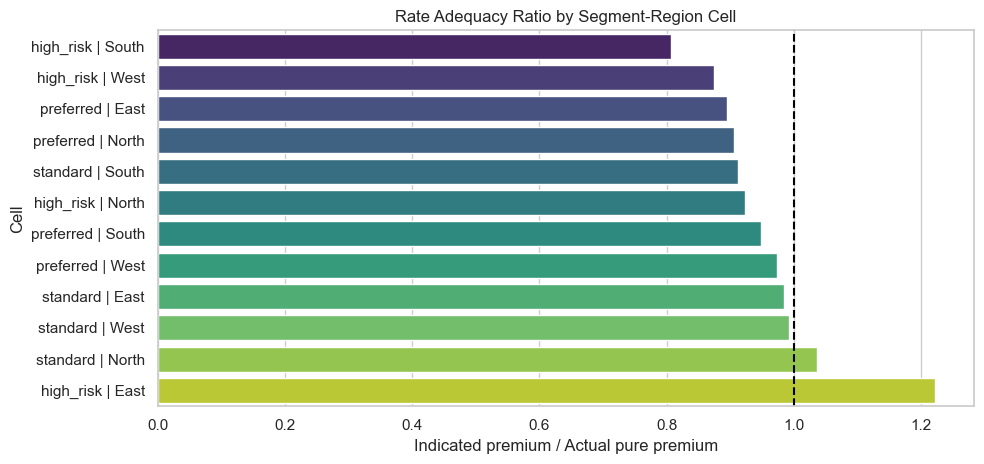

In [12]:
plt.figure(figsize=(10, 4.8))
plot_df = rate_adequacy.sort_values("rate_adequacy_ratio").copy()
plot_df["cell"] = plot_df["segment"] + " | " + plot_df["region"]

sns.barplot(data=plot_df, x="rate_adequacy_ratio", y="cell", palette="viridis")
plt.axvline(1.0, linestyle="--", color="black")
plt.title("Rate Adequacy Ratio by Segment-Region Cell")
plt.xlabel("Indicated premium / Actual pure premium")
plt.ylabel("Cell")
plt.tight_layout()
plt.show()

**What to read here.** Cells left of the dashed 1.0 line are **under-priced** — the technical premium does not cover observed loss for that segment × region combination; those are rate filing candidates. Cells well right of 1.0 are over-priced and risk losing business to competitors on renewal. The shape of this chart is the headline output of the pricing side of the workflow — it is what the chief underwriting officer sees first.

## 7. Building a paid-loss triangle for reserving

Pricing tells us whether *new* business earns its premium; reserving tells us whether the book's *existing* liabilities are adequately provisioned. We switch to a paid-loss triangle over 12 accident years and 12 development periods on the same underlying book, generated with a realistic S-shaped development pattern and a mild inflation trend across accident years.

In [13]:
accident_years = np.arange(2015, 2027)
dev_periods = np.arange(1, 13)

ult = np.random.lognormal(mean=10.7, sigma=0.23, size=len(accident_years)) * np.linspace(0.95, 1.08, len(accident_years))
cdf_pattern = np.array([0.17, 0.31, 0.45, 0.58, 0.68, 0.77, 0.84, 0.89, 0.93, 0.965, 0.985, 1.0])

triangle = pd.DataFrame(index=accident_years, columns=dev_periods, dtype=float)
for i, ay in enumerate(accident_years):
    max_dev = len(accident_years) - i
    for d in dev_periods[:max_dev]:
        noise = np.random.normal(1.0, 0.024)
        triangle.loc[ay, d] = ult[i] * cdf_pattern[d - 1] * noise
triangle = triangle.cummax(axis=1)

triangle.head()

,1,2,3,4,5,6,7,8,9,10,11,12
2015,13607.155610,24145.233290,35391.179759,44513.640493,53581.636758,60646.554763,64794.293459,69009.481819,71446.477388,78110.223325,78110.223325,78110.223325
2016,10326.564409,18626.219010,27726.307294,34468.959952,38468.796732,44253.353219,49935.309093,53101.640353,54601.328280,55289.292408,58648.502132,NaN
2017,10723.985913,17621.726151,26906.451687,36038.920329,40392.749324,48007.717542,50897.301425,53473.869834,54836.345039,57412.310270,NaN,NaN
2018,5456.907482,9774.774923,13862.384258,18674.971152,21594.248978,24602.634929,27212.867265,28390.485770,28707.436838,NaN,NaN,NaN
2019,5327.163746,9643.874763,15203.124251,18551.639298,22420.575756,24733.794299,27015.488600,28037.363375,NaN,NaN,NaN,NaN


## 8. Deterministic chain-ladder reserve

Standard chain-ladder: volume-weighted age-to-age factors, cumulative-to-ultimate development factors, and projected ultimates by accident year. IBNR per AY = projected ultimate − latest paid. The total is the central estimate a reserving actuary would bring to committee before any margin is booked.

In [14]:
# link ratios
factors = {}
for d in range(1, triangle.shape[1]):
    num = den = 0.0
    for ay in accident_years:
        if pd.notna(triangle.loc[ay, d]) and pd.notna(triangle.loc[ay, d + 1]):
            num += triangle.loc[ay, d + 1]
            den += triangle.loc[ay, d]
    factors[d] = num / den

f = pd.Series(factors)
cdf = {triangle.shape[1]: 1.0}
prod = 1.0
for d in range(triangle.shape[1] - 1, 0, -1):
    prod *= f[d]
    cdf[d] = prod
cdf = pd.Series(cdf).sort_index()

rows = []
for i, ay in enumerate(accident_years):
    latest_dev = len(accident_years) - i
    latest_paid = triangle.loc[ay, latest_dev]
    ultimate = latest_paid * cdf[latest_dev]
    ibnr = ultimate - latest_paid
    rows.append({
        "accident_year": ay,
        "latest_dev": latest_dev,
        "latest_paid": latest_paid,
        "ultimate": ultimate,
        "ibnr": ibnr,
    })

cl = pd.DataFrame(rows)
cl

,accident_year,latest_dev,latest_paid,ultimate,ibnr
0,2015,12,78110.223325,78110.223325,0.000000
1,2016,11,58648.502132,58648.502132,0.000000
2,2017,10,57412.310270,58858.042587,1445.732317
3,2018,9,28707.436838,31045.594603,2338.157765
4,2019,8,28037.363375,31155.779578,3118.416203
5,2020,7,41873.878167,49104.331115,7230.452948
6,2021,6,25846.422269,32780.596370,6934.174101
7,2022,5,30874.567286,45143.786191,14269.218905
8,2023,4,22134.883315,37361.482921,15226.599607
9,2024,3,19262.569909,41484.160515,22221.590606


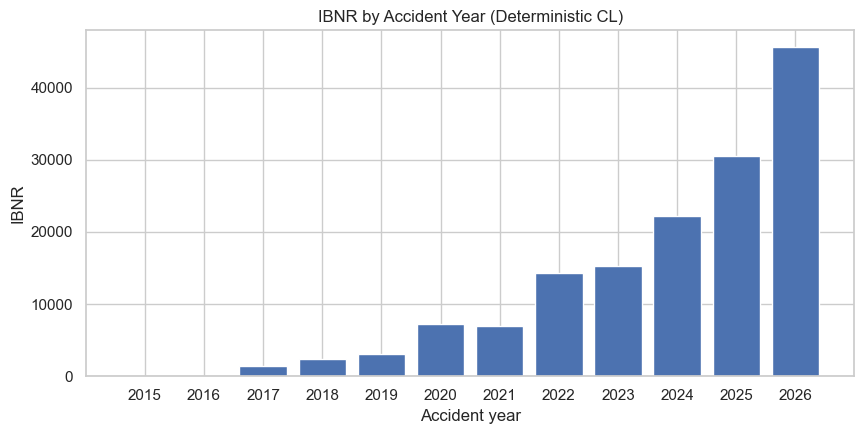

Deterministic total IBNR: 149,015


In [15]:
total_ibnr = cl["ibnr"].sum()

plt.figure(figsize=(8.8, 4.5))
plt.bar(cl["accident_year"].astype(str), cl["ibnr"], color="#4C72B0")
plt.title("IBNR by Accident Year (Deterministic CL)")
plt.xlabel("Accident year")
plt.ylabel("IBNR")
plt.tight_layout()
plt.show()

print(f"Deterministic total IBNR: {total_ibnr:,.0f}")

**What to read here.** IBNR concentrates heavily in the most recent accident years — they have the most development still to run. The shape of this bar chart should look broadly monotone from youngest (largest IBNR) to oldest (smallest or near-zero). Material IBNR on mature AYs would indicate the chain-ladder tail factor is missing adjustment and a Bornhuetter-Ferguson blend or explicit tail development assumption should be considered.

## 9. Bootstrap reserve uncertainty

The deterministic estimate alone cannot support a risk-margin conversation. We bootstrap by resampling observed age-to-age ratios (with small multiplicative jitter) and recomputing IBNR on each draw, 1,200 times. The resulting empirical distribution gives us P75 (working risk margin) and P95 (stress reserve) — the inputs the combined capital view will consume.

In [16]:
ratio_pool = {}
for d in range(1, triangle.shape[1]):
    ratio_pool[d] = np.array(
        [
            triangle.loc[ay, d + 1] / triangle.loc[ay, d]
            for ay in accident_years
            if pd.notna(triangle.loc[ay, d]) and pd.notna(triangle.loc[ay, d + 1])
        ]
    )

n_boot = 1200
boot_ibnr = []

for _ in range(n_boot):
    bf = {}
    for d in range(1, triangle.shape[1]):
        bf[d] = np.mean(np.random.choice(ratio_pool[d], size=max(20, len(ratio_pool[d])), replace=True)) * np.random.normal(1.0, 0.01)

    bcdf = {triangle.shape[1]: 1.0}
    prod = 1.0
    for d in range(triangle.shape[1] - 1, 0, -1):
        prod *= bf[d]
        bcdf[d] = prod

    total = 0.0
    for i, ay in enumerate(accident_years):
        latest_dev = len(accident_years) - i
        latest_paid = triangle.loc[ay, latest_dev]
        total += latest_paid * bcdf[latest_dev] - latest_paid

    boot_ibnr.append(total)

boot_ibnr = np.array(boot_ibnr)

reserve_dist = pd.Series(
    {
        "mean": np.mean(boot_ibnr),
        "std": np.std(boot_ibnr, ddof=1),
        "p75": np.quantile(boot_ibnr, 0.75),
        "p90": np.quantile(boot_ibnr, 0.90),
        "p95": np.quantile(boot_ibnr, 0.95),
    }
)
reserve_dist

mean    149408.689384
std      10428.696777
p75     156449.733009
p90     162917.875919
p95     166833.802760
dtype: float64

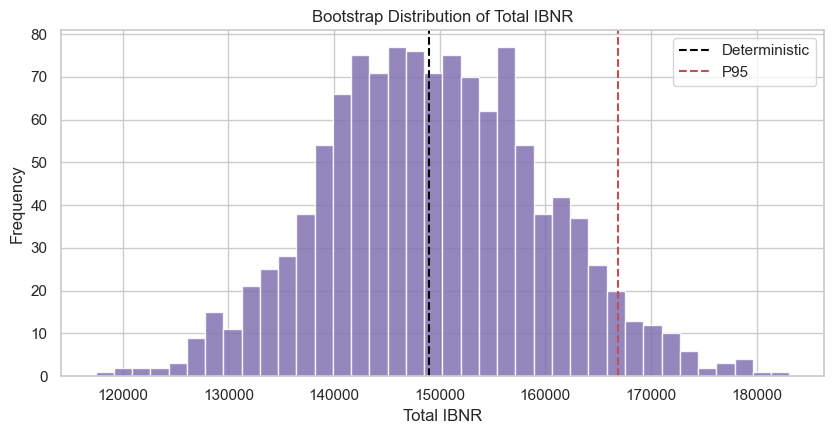

In [17]:
plt.figure(figsize=(8.5, 4.5))
plt.hist(boot_ibnr, bins=38, color="#8172B2", alpha=0.85)
plt.axvline(total_ibnr, linestyle="--", color="black", label="Deterministic")
plt.axvline(np.quantile(boot_ibnr, 0.95), linestyle="--", color="#C44E52", label="P95")
plt.title("Bootstrap Distribution of Total IBNR")
plt.xlabel("Total IBNR")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

**What to read here.** The black dashed line is the deterministic chain-ladder estimate; the red dashed line is the P95 bootstrap percentile. The *distance* between them is the reserve uncertainty we're quantifying — it is also the gap between booking a central estimate and booking a stress reserve. This gap is the number the risk committee is actually deciding on.

## 10. Combined pricing + reserving capital view

The moment the two workflows meet. **Pricing margin** (written premium − expected loss cost) is what this year's book is expected to generate before reserves. Subtracting P75 or P95 reserve percentiles gives the **margin after reserving under stress** — the real capital the book delivers once you account for the uncertainty in what's already on the balance sheet. A healthy book shows positive combined margin even at P95; a book that flips negative under stress is being priced (or reserved) too thin.

In [18]:
written_premium = (portfolio_scored["technical_premium"] * portfolio_scored["exposure"]).sum()
expected_loss_cost = (portfolio_scored["pure_premium_hat"] * portfolio_scored["exposure"]).sum()
reserve_p75 = np.quantile(boot_ibnr, 0.75)
reserve_p95 = np.quantile(boot_ibnr, 0.95)

capital_view = pd.Series(
    {
        "written_premium": written_premium,
        "expected_loss_cost_pricing": expected_loss_cost,
        "pricing_margin": written_premium - expected_loss_cost,
        "deterministic_ibnr": total_ibnr,
        "ibnr_p75": reserve_p75,
        "ibnr_p95": reserve_p95,
        "combined_margin_after_p75_reserve": written_premium - expected_loss_cost - reserve_p75,
        "combined_margin_after_p95_reserve": written_premium - expected_loss_cost - reserve_p95,
    }
)
capital_view

written_premium                      1.285316e+07
expected_loss_cost_pricing           8.956713e+06
pricing_margin                       3.896443e+06
deterministic_ibnr                   1.490152e+05
ibnr_p75                             1.564497e+05
ibnr_p95                             1.668338e+05
combined_margin_after_p75_reserve    3.739993e+06
combined_margin_after_p95_reserve    3.729609e+06
dtype: float64

## 11. Takeaways, limitations, and what a production version would add

**Takeaways**

- Pricing and reserving are the two sides of the same capital question and should be read on a single page. The "margin after P95 reserve" line is the most honest summary of a book's economics.
- Frequency/severity decomposition is not just a modelling choice — it gives pricing actuaries narrative they can defend to regulators and retain as the book evolves.
- Rate adequacy sliced by segment × region surfaces subsidies that headline loss ratios conceal. These are the cells where rate filings or exposure re-shaping have the largest impact.
- Bootstrap reserve percentiles (P75 as working margin, P95 as stress) turn a point estimate into a decision-grade distribution.

**Limitations**

- The frequency and severity models are evaluated here on simple RMSE/MAE. Production pricing needs lift curves, Gini, and reliability diagrams to defend a rating structure to a regulator.
- Reserving and pricing share the same underlying book in this notebook; in practice the two data pipelines diverge (e.g. triangle coverage, large-loss handling, coverage layers) and the mapping across them is where the real friction sits.
- Gradient-boosted pricing models are opaque by default. Any production deployment should ship SHAP / partial-dependence exhibits for rate-filing defensibility.
- The bootstrap captures parameter uncertainty but not method uncertainty — the choice of chain-ladder itself is not being benchmarked against Bornhuetter-Ferguson or Cape Cod here.

**What a production version would add**

- **Lift / Gini / reliability curves** on pricing models plus SHAP for interpretability.
- **Monotonicity constraints** on price-sensitive features for rate filing defensibility.
- **Paid vs. incurred triangle blending**, large-loss separation, and alternative reserving methods (BF, Cape Cod) as cross-checks.
- **Profitability tracking** that closes the loop: compare this year's written premium against the reserves that later develop on the same cohort, to validate both sides of the workflow empirically.